<a href="https://colab.research.google.com/github/audreynahir/telecom-analisis/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [2]:
import pandas as pd

df = pd.read_json("TelecomX_Data.json")

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [4]:
df.info()
df.dtypes
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

#🔧 Transformación

In [5]:
import pandas as pd

customer = pd.json_normalize(df["customer"])
phone = pd.json_normalize(df["phone"])
internet = pd.json_normalize(df["internet"])
account = pd.json_normalize(df["account"])

In [6]:
df_final = pd.concat(
    [df[["customerID","Churn"]], customer, phone, internet, account],
    axis=1
)

df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [7]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [14]:
df_final.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [15]:
df_final.duplicated().sum()
df_final = df_final.drop_duplicates()

In [18]:
df_final.dtypes


,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


In [19]:
df_final["Contract"].unique()

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

In [20]:
df_final["Contract"].unique()

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

In [21]:
columnas_categoricas = ["gender","Contract","InternetService","PhoneService","Churn"]

for col in columnas_categoricas:
    print(col)
    print(df_final[col].unique())
    print()

gender
['Female' 'Male']

Contract
['One year' 'Month-to-month' 'Two year']

InternetService
['DSL' 'Fiber optic' 'No']

PhoneService
['Yes' 'No']

Churn
['No' 'Yes' '']



In [22]:
df_final.describe()

,SeniorCitizen,tenure,Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [24]:
df_final = df_final.dropna()
df_final = df_final.fillna(0)

In [27]:
# Convertir Charges.Total a numérico
df_final["Charges.Total"] = pd.to_numeric(df_final["Charges.Total"], errors="coerce")

# Eliminar valores nulos generados en la conversión
df_final = df_final.dropna()

# Verificar cambios
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7256 non-null   object 
 1   Churn             7256 non-null   object 
 2   gender            7256 non-null   object 
 3   SeniorCitizen     7256 non-null   int64  
 4   Partner           7256 non-null   object 
 5   Dependents        7256 non-null   object 
 6   tenure            7256 non-null   int64  
 7   PhoneService      7256 non-null   object 
 8   MultipleLines     7256 non-null   object 
 9   InternetService   7256 non-null   object 
 10  OnlineSecurity    7256 non-null   object 
 11  OnlineBackup      7256 non-null   object 
 12  DeviceProtection  7256 non-null   object 
 13  TechSupport       7256 non-null   object 
 14  StreamingTV       7256 non-null   object 
 15  StreamingMovies   7256 non-null   object 
 16  Contract          7256 non-null   object 
 17  

In [53]:
df_final.loc[:, "Churn"] = df_final["Churn"].map({"Yes": 1, "No": 0})

df_final = df_final.rename(columns={
    "Charges.Monthly": "MonthlyCharges",
    "Charges.Total": "TotalCharges"
})

df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0002-ORFBO,NaN,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,NaN,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,NaN,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,NaN,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,NaN,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


#📊 Carga y análisis

In [29]:
df_final.describe()

,Churn,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7256.0000,7256.000000,7256.000000,7256.000000
mean,0.265785,0.1629,32.395535,64.755423,2280.634213
std,0.441782,0.3693,24.558067,30.125739,2268.632997
min,0.000000,0.0000,1.000000,18.250000,18.800000
25%,0.000000,0.0000,9.000000,35.450000,400.225000
50%,0.000000,0.0000,29.000000,70.300000,1391.000000
75%,1.000000,0.0000,55.000000,89.900000,3785.300000
max,1.000000,1.0000,72.000000,118.750000,8684.800000


In [30]:
df_final[["tenure","MonthlyCharges","TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7256.000000,7256.000000,7256.000000
mean,32.395535,64.755423,2280.634213
std,24.558067,30.125739,2268.632997
min,1.000000,18.250000,18.800000
25%,9.000000,35.450000,400.225000
50%,29.000000,70.300000,1391.000000
75%,55.000000,89.900000,3785.300000
max,72.000000,118.750000,8684.800000


In [31]:
df_final[["tenure","MonthlyCharges","TotalCharges"]].median()

,0
tenure,29.0
MonthlyCharges,70.3
TotalCharges,1391.0


In [32]:
df_final[["tenure","MonthlyCharges","TotalCharges"]].std()

,0
tenure,24.558067
MonthlyCharges,30.125739
TotalCharges,2268.632997


In [36]:
df_final["Churn"].value_counts()

,count
Churn,
0.0,5163
1.0,1869


In [38]:
df_final = df_final.dropna(subset=["Churn"])
df_final["Churn"].value_counts()

,count
Churn,
0.0,5163
1.0,1869


In [40]:
df_final["Churn"].isnull().sum()

np.int64(0)

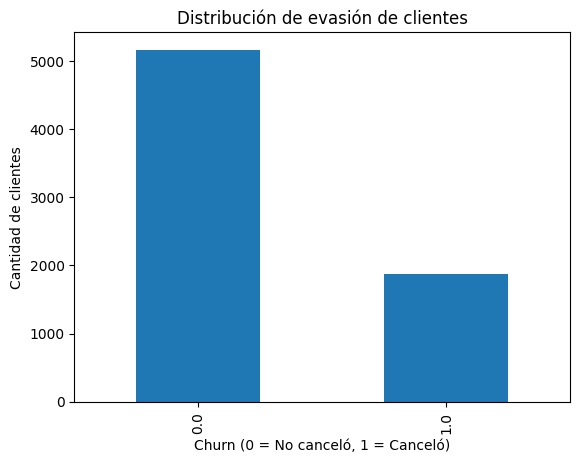

In [43]:
import matplotlib.pyplot as plt

df_final["Churn"].value_counts().plot(kind="bar")

plt.title("Distribución de evasión de clientes")
plt.xlabel("Churn (0 = No canceló, 1 = Canceló)")
plt.ylabel("Cantidad de clientes")
plt.show()

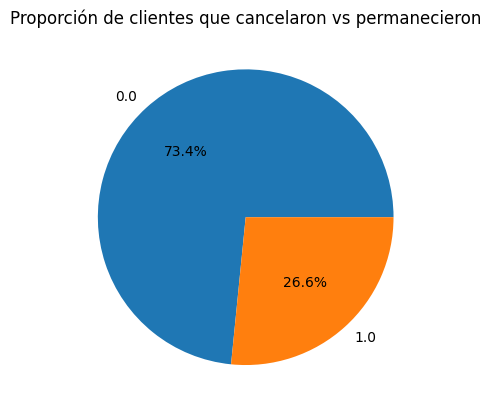

In [42]:
df_final["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Proporción de clientes que cancelaron vs permanecieron")
plt.ylabel("")
plt.show()

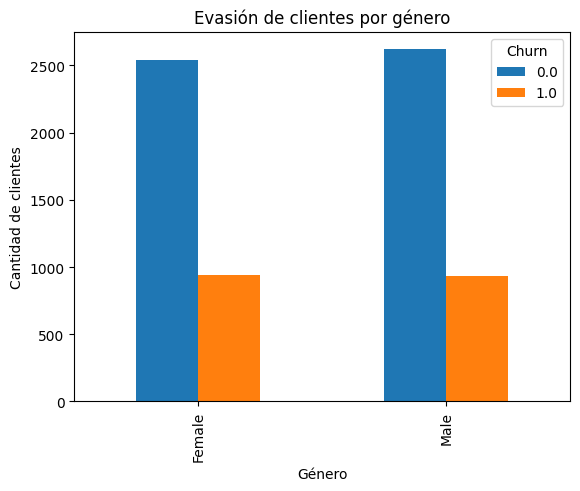

In [44]:
import matplotlib.pyplot as plt

pd.crosstab(df_final["gender"], df_final["Churn"]).plot(kind="bar")

plt.title("Evasión de clientes por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de clientes")
plt.show()

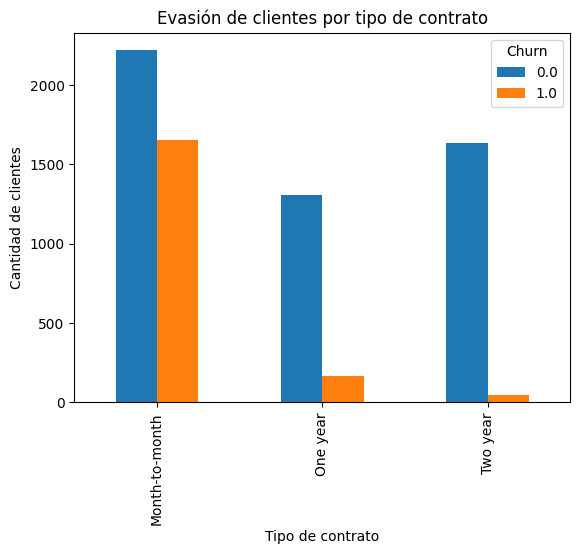

In [45]:
pd.crosstab(df_final["Contract"], df_final["Churn"]).plot(kind="bar")

plt.title("Evasión de clientes por tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")
plt.show()

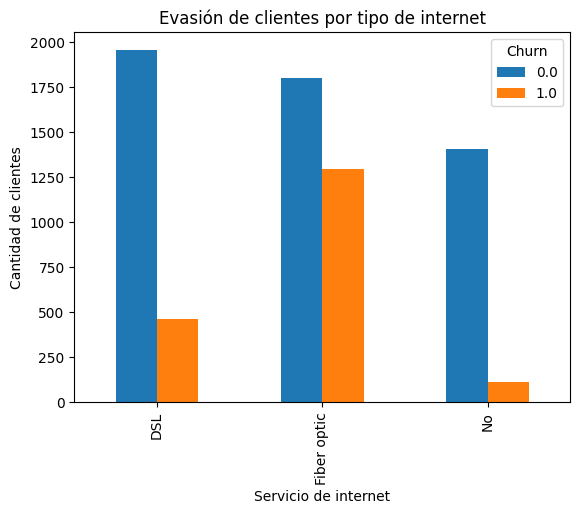

In [46]:
pd.crosstab(df_final["InternetService"], df_final["Churn"]).plot(kind="bar")

plt.title("Evasión de clientes por tipo de internet")
plt.xlabel("Servicio de internet")
plt.ylabel("Cantidad de clientes")
plt.show()

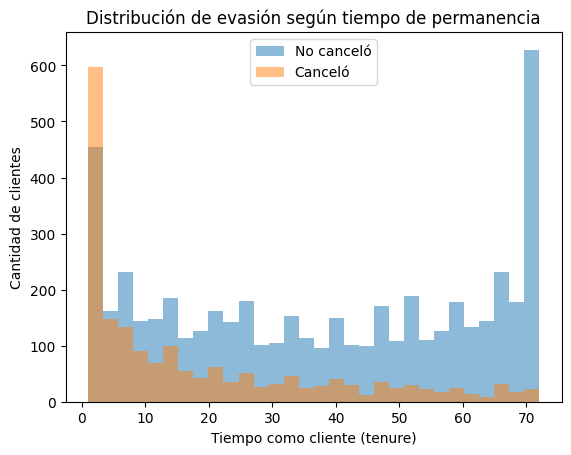

In [47]:
import matplotlib.pyplot as plt

plt.hist(df_final[df_final["Churn"]==0]["tenure"], bins=30, alpha=0.5, label="No canceló")
plt.hist(df_final[df_final["Churn"]==1]["tenure"], bins=30, alpha=0.5, label="Canceló")

plt.title("Distribución de evasión según tiempo de permanencia")
plt.xlabel("Tiempo como cliente (tenure)")
plt.ylabel("Cantidad de clientes")
plt.legend()
plt.show()

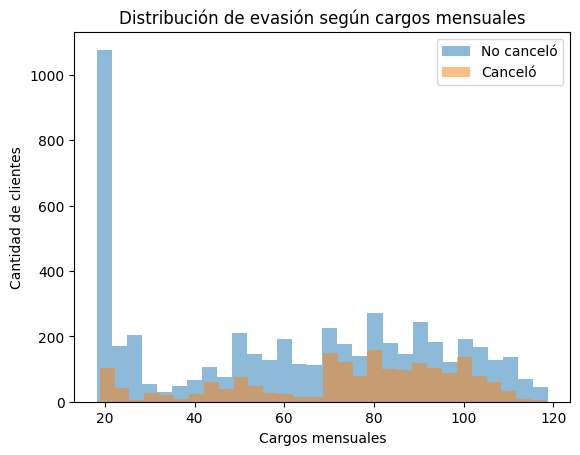

In [48]:
plt.hist(df_final[df_final["Churn"]==0]["MonthlyCharges"], bins=30, alpha=0.5, label="No canceló")
plt.hist(df_final[df_final["Churn"]==1]["MonthlyCharges"], bins=30, alpha=0.5, label="Canceló")

plt.title("Distribución de evasión según cargos mensuales")
plt.xlabel("Cargos mensuales")
plt.ylabel("Cantidad de clientes")
plt.legend()
plt.show()

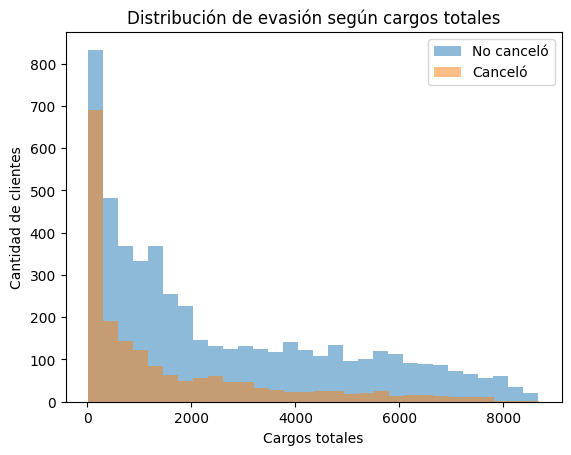

In [49]:
plt.hist(df_final[df_final["Churn"]==0]["TotalCharges"], bins=30, alpha=0.5, label="No canceló")
plt.hist(df_final[df_final["Churn"]==1]["TotalCharges"], bins=30, alpha=0.5, label="Canceló")

plt.title("Distribución de evasión según cargos totales")
plt.xlabel("Cargos totales")
plt.ylabel("Cantidad de clientes")
plt.legend()
plt.show()

#📄Informe final

# Informe Final – Análisis de Evasión de Clientes (Churn)

## Introducción

La evasión de clientes, conocida como *Churn*, es un problema importante para las empresas de telecomunicaciones, ya que implica la pérdida de clientes y, en consecuencia, de ingresos. Comprender por qué los clientes deciden cancelar un servicio permite a las empresas implementar estrategias de retención más efectivas.

El objetivo de este análisis es explorar el conjunto de datos de clientes para identificar patrones asociados con la cancelación del servicio. A través de técnicas de análisis exploratorio de datos, se busca detectar qué variables influyen en la evasión y generar información útil que permita reducir la pérdida de clientes.

---

## Limpieza y Tratamiento de Datos

Para preparar los datos para el análisis se realizaron diferentes procesos de limpieza y transformación.

Primero se importó el conjunto de datos y se revisó su estructura para identificar las variables disponibles. Posteriormente se verificaron los tipos de datos y la presencia de valores faltantes.

Entre las principales acciones realizadas se encuentran:

- Exploración inicial del dataset para comprender su estructura.
- Verificación de nombres de columnas y tipos de datos.
- Conversión de variables numéricas como **MonthlyCharges** y **TotalCharges** al tipo numérico.
- Eliminación de registros con valores faltantes en la variable objetivo **Churn**.
- Revisión de la consistencia de las variables categóricas.

Estos pasos permitieron obtener un conjunto de datos limpio y adecuado para el análisis exploratorio.

---

## Análisis Exploratorio de Datos

El análisis exploratorio permitió comprender mejor el comportamiento de los clientes y detectar factores asociados con la evasión.

### Distribución general de Churn

El análisis mostró que:

- **5163 clientes (73.4%)** permanecen en el servicio.
- **1869 clientes (26.6%)** cancelaron el servicio.

Esto indica que aproximadamente **1 de cada 4 clientes abandona la empresa**, lo que representa una tasa de evasión considerable.

---

### Churn según tipo de contrato

El tipo de contrato presenta una relación muy clara con la evasión:

- **Contrato mensual (Month-to-month): 42.7% de churn**
- **Contrato anual: 11.3% de churn**
- **Contrato de dos años: 2.8% de churn**

Esto indica que los clientes con contratos mensuales tienen una probabilidad significativamente mayor de cancelar el servicio.

---

### Churn según método de pago

El análisis del método de pago mostró diferencias importantes:

- **Electronic check: 45.3% de churn**
- Bank transfer automático: 16.7%
- Tarjeta de crédito automática: 15.3%
- Cheque enviado por correo: 19.2%

Los clientes que utilizan **electronic check presentan la mayor tasa de evasión**, lo que podría indicar menor estabilidad o menor compromiso con el servicio.

---

### Churn según tipo de servicio de internet

También se observaron diferencias importantes según el tipo de internet:

- **Fibra óptica: 41.9% de churn**
- DSL: 19.0%
- Sin servicio de internet: 7.4%

Los clientes con **fibra óptica presentan una tasa de cancelación considerablemente mayor**.

---

### Análisis de variables numéricas

Se analizaron variables como el tiempo de permanencia (*tenure*), los cargos mensuales y los cargos totales.

Los resultados muestran:

| Estado del cliente | Tenure promedio | Cargo mensual | Cargo total |
|---|---|---|---|
Clientes activos | 37.65 meses | 61.30 | 2555 |
Clientes que cancelaron | 17.98 meses | 74.44 | 1531 |

Esto revela tres patrones importantes:

1. Los clientes que cancelan permanecen **mucho menos tiempo en la empresa**.
2. Los clientes que abandonan tienen **cargos mensuales más altos**.
3. Los clientes que se van acumulan **menos gasto total**, lo que indica que abandonan relativamente temprano.

---

## Conclusiones e Insights

El análisis permitió identificar varios factores asociados con la evasión de clientes.

Uno de los factores más importantes es el **tipo de contrato**. Los clientes con contratos mensuales presentan una tasa de evasión muy superior a aquellos con contratos de mayor duración.

El **método de pago** también muestra diferencias importantes, ya que los clientes que utilizan electronic check presentan la mayor proporción de cancelaciones.

El **tipo de servicio de internet**, particularmente la fibra óptica, presenta una tasa de evasión significativamente más alta, lo que podría indicar problemas de costo, calidad del servicio o expectativas del cliente.

Finalmente, el **tiempo de permanencia** es un factor clave. Los clientes que abandonan el servicio suelen hacerlo en etapas tempranas, lo que sugiere que la experiencia inicial del cliente es determinante para su fidelización.

---

## Recomendaciones

A partir de los resultados obtenidos, se proponen las siguientes estrategias para reducir la evasión de clientes:

**1. Incentivar contratos de largo plazo**

Promover contratos anuales o de dos años mediante descuentos o beneficios puede ayudar a reducir la tasa de cancelación.

**2. Mejorar la experiencia de clientes nuevos**

Dado que muchos clientes abandonan el servicio durante los primeros meses, es recomendable implementar programas de acompañamiento o fidelización para nuevos usuarios.

**3. Analizar el servicio de fibra óptica**

La alta tasa de evasión en clientes de fibra óptica sugiere la necesidad de revisar aspectos como precios, calidad del servicio o soporte técnico.

**4. Evaluar el método de pago electronic check**

Este método presenta la mayor tasa de churn, por lo que podría ser útil analizar el perfil de estos clientes o incentivar métodos de pago automáticos más estables.

**5. Implementar modelos predictivos de churn**

Como trabajo futuro, se recomienda desarrollar modelos de machine learning que permitan predecir qué clientes tienen mayor riesgo de cancelar el servicio, lo que permitiría aplicar estrategias de retención de forma anticipada.

---

## Conclusión General

El análisis exploratorio permitió identificar factores importantes relacionados con la evasión de clientes. Variables como el tipo de contrato, el método de pago, el tipo de servicio de internet y el tiempo de permanencia influyen significativamente en la probabilidad de cancelación.

Estos resultados proporcionan información valiosa que puede ayudar a las empresas a diseñar estrategias de retención más efectivas, mejorar la experiencia del cliente y reducir la pérdida de usuarios.